In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
%matplotlib inline

In [2]:
df = pd.read_csv(r"C:\Users\ASUS\Downloads\pizza_sales.csv")

In [3]:
df.head(10)

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01-01-2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01-01-2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
5,6,2,thai_ckn_l,1,01-01-2015,11:57:40,20.75,20.75,L,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza
6,7,3,ital_supr_m,1,01-01-2015,12:12:28,16.50,16.50,M,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
7,8,3,prsc_argla_l,1,01-01-2015,12:12:28,20.75,20.75,L,Supreme,"Prosciutto di San Daniele, Arugula, Mozzarella...",The Prosciutto and Arugula Pizza
8,9,4,ital_supr_m,1,01-01-2015,12:16:31,16.50,16.50,M,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
9,10,5,ital_supr_m,1,01-01-2015,12:21:30,16.50,16.50,M,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


In [4]:
import datetime as dt

In [5]:
df['order_date'] =pd.to_datetime(df['order_date'],format='%d-%m-%Y')

In [6]:
df['Month'] = df['order_date'].dt.month_name().str[:3]

In [7]:
df['DayWeek'] = df['order_date'].dt.day_name().str[:3]

In [8]:
df.head(3)

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,Month,DayWeek
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza,Jan,Thu
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,Jan,Thu
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,Jan,Thu


In [9]:
df =df.drop(columns=['pizza_ingredients','order_time'],axis=1)

In [10]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,unit_price,total_price,pizza_size,pizza_category,pizza_name,Month,DayWeek
0,1,1,hawaiian_m,1,2015-01-01,13.25,13.25,M,Classic,The Hawaiian Pizza,Jan,Thu
1,2,2,classic_dlx_m,1,2015-01-01,16.00,16.00,M,Classic,The Classic Deluxe Pizza,Jan,Thu
2,3,2,five_cheese_l,1,2015-01-01,18.50,18.50,L,Veggie,The Five Cheese Pizza,Jan,Thu
3,4,2,ital_supr_l,1,2015-01-01,20.75,20.75,L,Supreme,The Italian Supreme Pizza,Jan,Thu
4,5,2,mexicana_m,1,2015-01-01,16.00,16.00,M,Veggie,The Mexicana Pizza,Jan,Thu


In [34]:
d={'Total_Revenue':df['total_price'].sum(),'Total_pizza_sold':df['quantity'].sum(),
   'Total_Order':df['order_id'].nunique(),'Avg_pizza_per_order':df['quantity'].sum()/df['order_id'].nunique(),
   'Avg_total_price_per_order':df['total_price'].sum()/df['order_id'].nunique()}

In [35]:
d

{'Total_Revenue': np.float64(817860.0499999999),
 'Total_pizza_sold': np.int64(49574),
 'Total_Order': 21350,
 'Avg_pizza_per_order': np.float64(2.321967213114754),
 'Avg_total_price_per_order': np.float64(38.30726229508196)}

In [32]:
dff=pd.DataFrame([d])

In [33]:
dff

,Total_Revenue,Total_pizza_sold,Total_Order,Avg_pizza_per_order,Avg_total_price_per_order
0,817860.05,49574,21350,2.321967,38.307262


In [38]:
df1 = df.groupby('pizza_size')['quantity'].sum().reset_index()

In [37]:
df2= df.groupby('pizza_category')['quantity'].sum().reset_index()

In [39]:
df1

,pizza_size,quantity
0,L,18956
1,M,15635
2,S,14403
3,XL,552
4,XXL,28


([<matplotlib.patches.Wedge at 0x1b0e1aba510>,
 [Text(0.39728554155812246, 1.0257505537258411, 'L'),
  Text(-1.0653185710846027, -0.2740371181104135, 'M'),
  Text(0.6069990580219844, -0.9173615119245105, 'S'),
  Text(1.0991836053074349, -0.04237218218772142, 'XL'),
  Text(1.8999970098194234, -0.003370857049886852, 'XXL')],
 [Text(0.21670120448624858, 0.5595003020322769, '38.2%'),
  Text(-0.5810828569552378, -0.14947479169658914, '31.5%'),
  Text(0.33109039528471873, -0.5003790065042784, '29.1%'),
  Text(0.5995546938040553, -0.023112099375120772, '1.1%'),
  Text(1.3999977967090487, -0.0024837894051797857, '0.1%')])

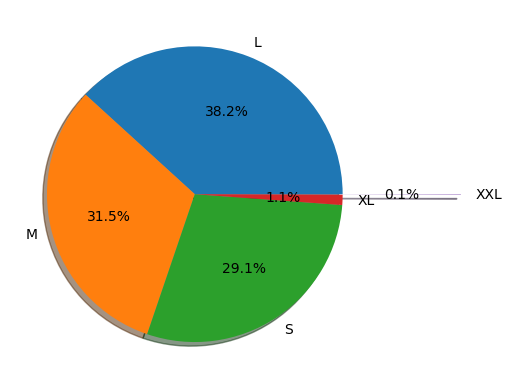

In [40]:
plt.pie(df1['quantity'],labels=df1['pizza_size'],autopct="%1.1f%%",shadow=True,explode=[0,0,0,0,0.8])

([<matplotlib.patches.Wedge at 0x1b0e1aa8550>,
 [Text(0.8411434105235585, 0.7088566589465014, 'Chicken'),
  Text(-0.8381139278390906, 0.8588160710898067, 'Classic'),
  Text(-0.6790047868528056, -0.8654204177340492, 'Supreme'),
  Text(0.8136361180951905, -0.7402676997755537, 'Veggie')],
 [Text(0.45880549664921366, 0.3866490866980916, '22.3%'),
  Text(-0.4888997912394694, 0.5009760414690538, '30.0%'),
  Text(-0.37036624737425755, -0.4720475005822086, '24.2%'),
  Text(0.443801518961013, -0.4037823816957566, '23.5%')])

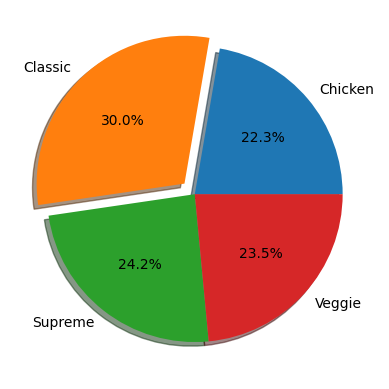

In [41]:
plt.pie(df2['quantity'],labels=df2['pizza_category'],autopct="%1.1f%%",shadow=True, explode=[0,0.1,0,0])

In [70]:
df3= df.groupby('pizza_name').agg({'quantity':'sum','total_price':'sum','order_id':'nunique'}).reset_index()

In [43]:
df4=df3.nlargest(5,'quantity')

In [54]:
df4

,pizza_name,quantity,total_price
7,The Classic Deluxe Pizza,2453,38180.50
0,The Barbecue Chicken Pizza,2432,42768.00
12,The Hawaiian Pizza,2422,32273.25
20,The Pepperoni Pizza,2418,30161.75
30,The Thai Chicken Pizza,2371,43434.25


C:\Users\ASUS\AppData\Local\Temp\ipykernel_1028\1413188120.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_1028\1413188120.py:5: UserWarning:

Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14



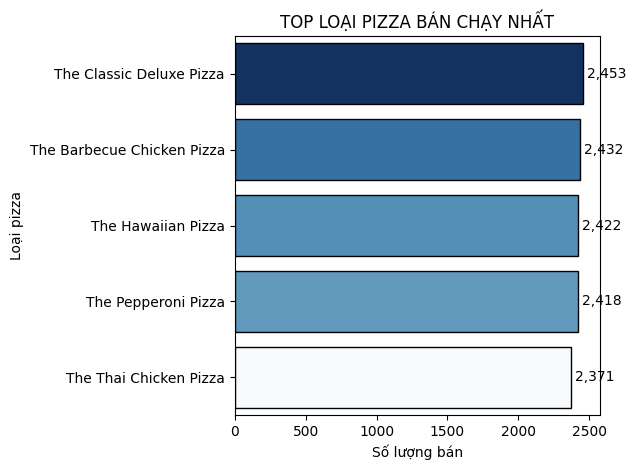

In [75]:
plt.Figure(figsize=(10,20))
values = df4['quantity'].values
norm = plt.Normalize(values.min(), values.max())
colors = plt.cm.Blues(norm(values))
ax=sns.barplot(
    x='quantity',
    y='pizza_name',
    data=df4,
    palette=colors,
    edgecolor='black'
)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}'.format, padding=3, fontsize=10)
plt.title('TOP LOẠI PIZZA BÁN CHẠY NHẤT')
plt.xlabel('Số lượng bán')
plt.ylabel('Loại pizza')
plt.tight_layout()

In [45]:
df5=df3.nlargest(5,'total_price')

In [46]:
df5


,pizza_name,quantity,total_price
30,The Thai Chicken Pizza,2371,43434.25
0,The Barbecue Chicken Pizza,2432,42768.00
4,The California Chicken Pizza,2370,41409.50
7,The Classic Deluxe Pizza,2453,38180.50
26,The Spicy Italian Pizza,1924,34831.25


C:\Users\ASUS\AppData\Local\Temp\ipykernel_1028\316634975.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_1028\316634975.py:5: UserWarning:

Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14



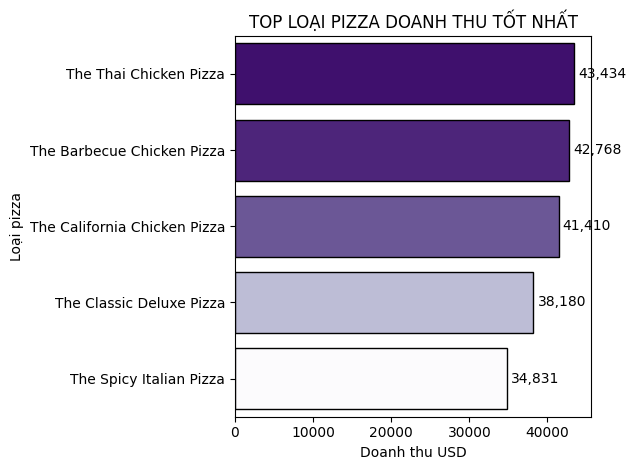

In [76]:
plt.Figure(figsize=(10,20))
values = df5['total_price'].values
norm = plt.Normalize(values.min(),values.max())
colors=plt.cm.Purples(norm(values))
ax=sns.barplot(
    x='total_price',
    y='pizza_name',
    data=df5,
    palette=colors,
    edgecolor='black'
)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}'.format, padding=3, fontsize=10)
plt.title('TOP LOẠI PIZZA DOANH THU TỐT NHẤT')
plt.xlabel('Doanh thu USD')
plt.ylabel('Loại pizza')
plt.tight_layout()

In [71]:
df11=df3.nlargest(5,'order_id')

In [72]:
df11

,pizza_name,quantity,total_price,order_id
7,The Classic Deluxe Pizza,2453,38180.50,2329
12,The Hawaiian Pizza,2422,32273.25,2280
20,The Pepperoni Pizza,2418,30161.75,2278
0,The Barbecue Chicken Pizza,2432,42768.00,2273
30,The Thai Chicken Pizza,2371,43434.25,2225


C:\Users\ASUS\AppData\Local\Temp\ipykernel_1028\466627830.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_1028\466627830.py:5: UserWarning:

Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14



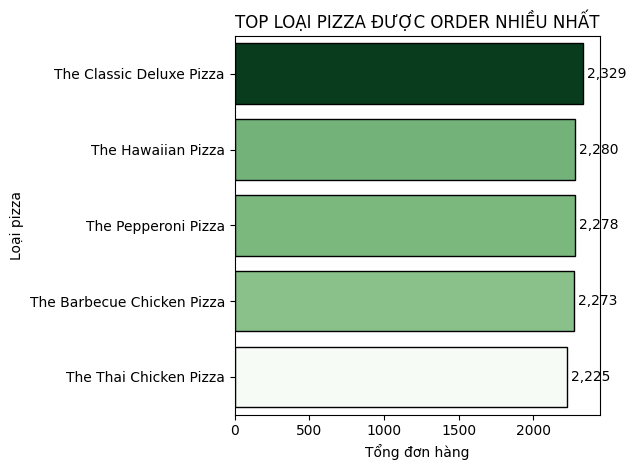

In [78]:
plt.Figure(figsize=(10,20))
values= df11['order_id'].values
norm = plt.Normalize(values.min(),values.max())
colors=plt.cm.Greens(norm(values))
ax=sns.barplot(
    x='order_id',
    y='pizza_name',
    data=df11,
    palette=colors,
    edgecolor='black'
)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}'.format, padding=3, fontsize=10)
plt.title('TOP LOẠI PIZZA ĐƯỢC ORDER NHIỀU NHẤT')
plt.xlabel('Tổng đơn hàng')
plt.ylabel('Loại pizza')
plt.tight_layout()

In [48]:
df6=df3.nsmallest(5,'quantity')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1028\3938046158.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_1028\3938046158.py:5: UserWarning:

Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14



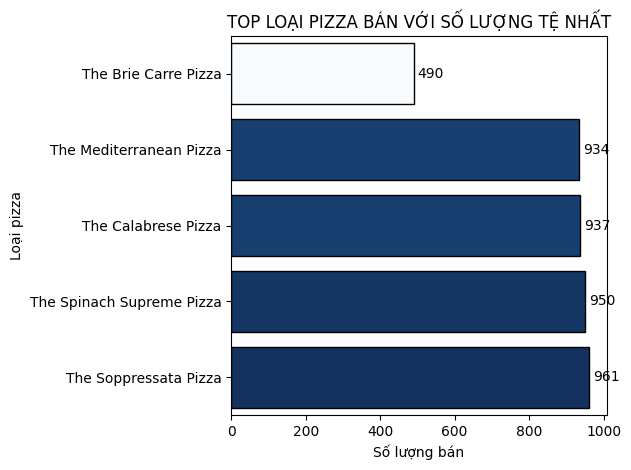

In [79]:
plt.Figure(figsize=(10,20))
values = df6['quantity'].values
norm = plt.Normalize(values.min(), values.max())
colors = plt.cm.Blues(norm(values))
ax=sns.barplot(
    x='quantity',
    y='pizza_name',
    data=df6,
    palette=colors,
    edgecolor='black'
)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}'.format, padding=3, fontsize=10)
plt.title('TOP LOẠI PIZZA BÁN VỚI SỐ LƯỢNG TỆ NHẤT')
plt.xlabel('Số lượng bán')
plt.ylabel('Loại pizza')
plt.tight_layout()

In [50]:
df7=df3.nsmallest(5,'total_price')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1028\2676871142.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_1028\2676871142.py:5: UserWarning:

Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14



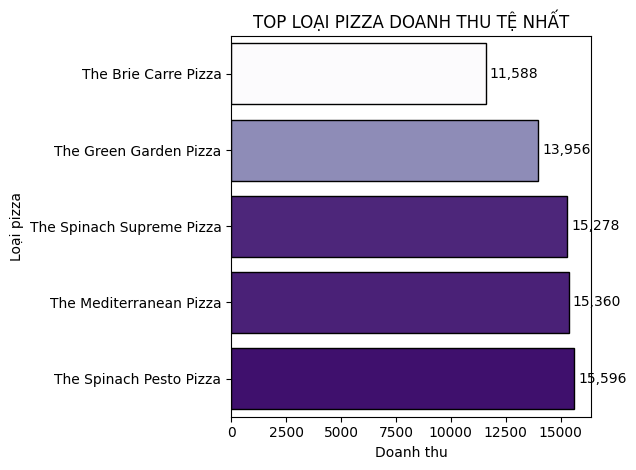

In [80]:
plt.Figure(figsize=(10,20))
values = df7['total_price'].values
norm = plt.Normalize(values.min(),values.max())
colors=plt.cm.Purples(norm(values))
ax = sns.barplot(x='total_price',
                y='pizza_name',
                data=df7, 
                palette=colors, 
                edgecolor='black')
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}'.format, padding =3,fontsize=10)
plt.title('TOP LOẠI PIZZA DOANH THU TỆ NHẤT')
plt.xlabel('Doanh thu')
plt.ylabel('Loại pizza')
plt.tight_layout()




In [81]:
df12=df3.nsmallest(5,'order_id')

In [82]:
df12

,pizza_name,quantity,total_price,order_id
2,The Brie Carre Pizza,490,11588.50,480
16,The Mediterranean Pizza,934,15360.50,912
3,The Calabrese Pizza,937,15934.25,918
28,The Spinach Supreme Pizza,950,15277.75,918
6,The Chicken Pesto Pizza,973,16701.75,938


C:\Users\ASUS\AppData\Local\Temp\ipykernel_1028\14266280.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_1028\14266280.py:5: UserWarning:

Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14



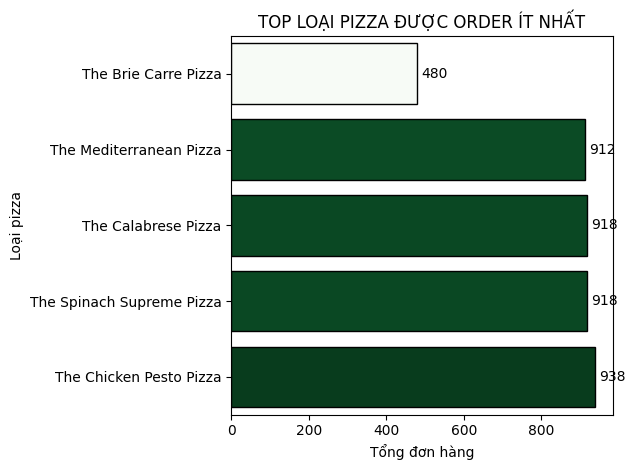

In [83]:
plt.Figure(figsize=(10,20))
values= df12['order_id'].values
norm = plt.Normalize(values.min(),values.max())
colors=plt.cm.Greens(norm(values))
ax=sns.barplot(
    x='order_id',
    y='pizza_name',
    data=df12,
    palette=colors,
    edgecolor='black'
)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}'.format, padding=3, fontsize=10)
plt.title('TOP LOẠI PIZZA ĐƯỢC ORDER ÍT NHẤT')
plt.xlabel('Tổng đơn hàng')
plt.ylabel('Loại pizza')
plt.tight_layout()

In [52]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,unit_price,total_price,pizza_size,pizza_category,pizza_name,Month,DayWeek
0,1,1,hawaiian_m,1,2015-01-01,13.25,13.25,M,Classic,The Hawaiian Pizza,Jan,Thu
1,2,2,classic_dlx_m,1,2015-01-01,16.00,16.00,M,Classic,The Classic Deluxe Pizza,Jan,Thu
2,3,2,five_cheese_l,1,2015-01-01,18.50,18.50,L,Veggie,The Five Cheese Pizza,Jan,Thu
3,4,2,ital_supr_l,1,2015-01-01,20.75,20.75,L,Supreme,The Italian Supreme Pizza,Jan,Thu
4,5,2,mexicana_m,1,2015-01-01,16.00,16.00,M,Veggie,The Mexicana Pizza,Jan,Thu


In [55]:
df8=df.groupby('Month')['order_id'].nunique().reset_index()

In [56]:
df8

,Month,order_id
0,Apr,1799
1,Aug,1841
2,Dec,1680
3,Feb,1685
4,Jan,1845
5,Jul,1935
6,Jun,1773
7,Mar,1840
8,May,1853
9,Nov,1792


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

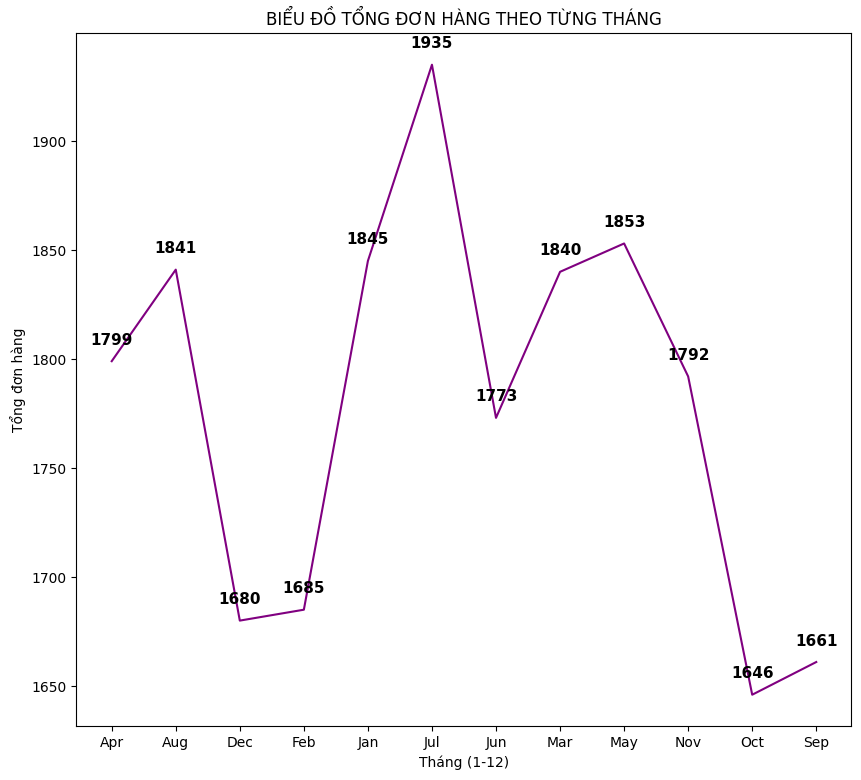

In [57]:
plt.figure(figsize=(10,9))
ax=sns.lineplot(x='Month', y='order_id',data=df8,markers=True, color='Purple')
for i,row in df8.iterrows():#df8.iterrows(): Duyệt qua từng dòng trong DataFrame,i: Chỉ số index của dòng,row: Chứa toàn bộ dữ liệu của dòng hiện tại
    ax.annotate(f'{row['order_id']}',#Hiển thị giá trị order_id của dòng hiện tại
                (row['Month'],row['order_id']),#Xác định tọa độ điểm cần gắn nhãn
                textcoords='offset points',#Tọa độ của văn bản được tính theo "điểm offset" so với vị trí gốc
                xytext=(0,12),#nghĩa là cách điểm gốc 0 điểm theo chiều ngang và 12 điểm theo chiều dọc
                ha ='center',
                fontsize =11,
                fontweight='bold')
plt.title('BIỂU ĐỒ TỔNG ĐƠN HÀNG THEO TỪNG THÁNG')
plt.xlabel('Tháng (1-12)')
plt.ylabel('Tổng đơn hàng')
plt.tight_layout

In [58]:
df9=df.groupby('DayWeek')['order_id'].nunique().reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']).reset_index()

In [59]:
df9

,DayWeek,order_id
0,Mon,2794
1,Tue,2973
2,Wed,3024
3,Thu,3239
4,Fri,3538
5,Sat,3158
6,Sun,2624


C:\Users\ASUS\AppData\Local\Temp\ipykernel_1028\818160801.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='DayWeek', y ='order_id', data =df9,palette='coolwarm',edgecolor='Black')


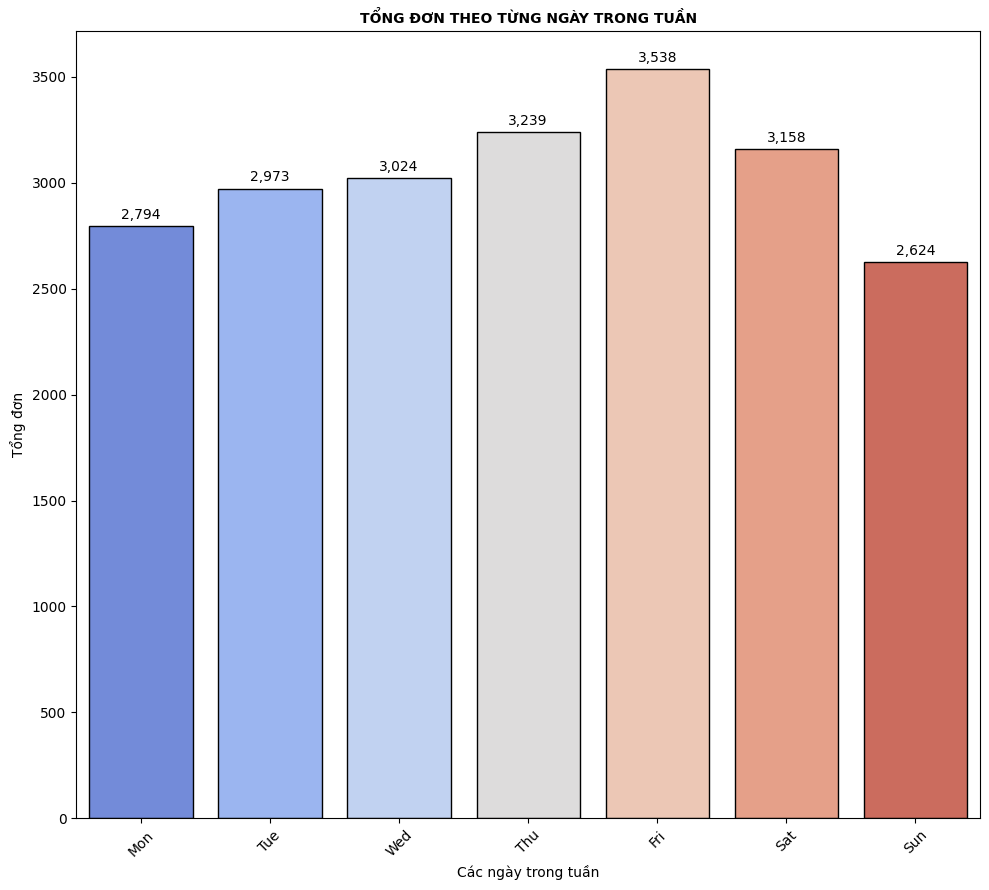

In [60]:
plt.figure(figsize=(10,9))
ax = sns.barplot(x='DayWeek', y ='order_id', data =df9,palette='coolwarm',edgecolor='Black')
for container in ax.containers:
    ax.bar_label(container,fmt='{:,.0f}'.format, label_type='edge',padding=3, fontsize=10)
plt.title('TỔNG ĐƠN THEO TỪNG NGÀY TRONG TUẦN', fontsize=10, fontweight='bold')
plt.ylabel('Tổng đơn')
plt.xlabel('Các ngày trong tuần')
plt.xticks(rotation=45)
plt.tight_layout()

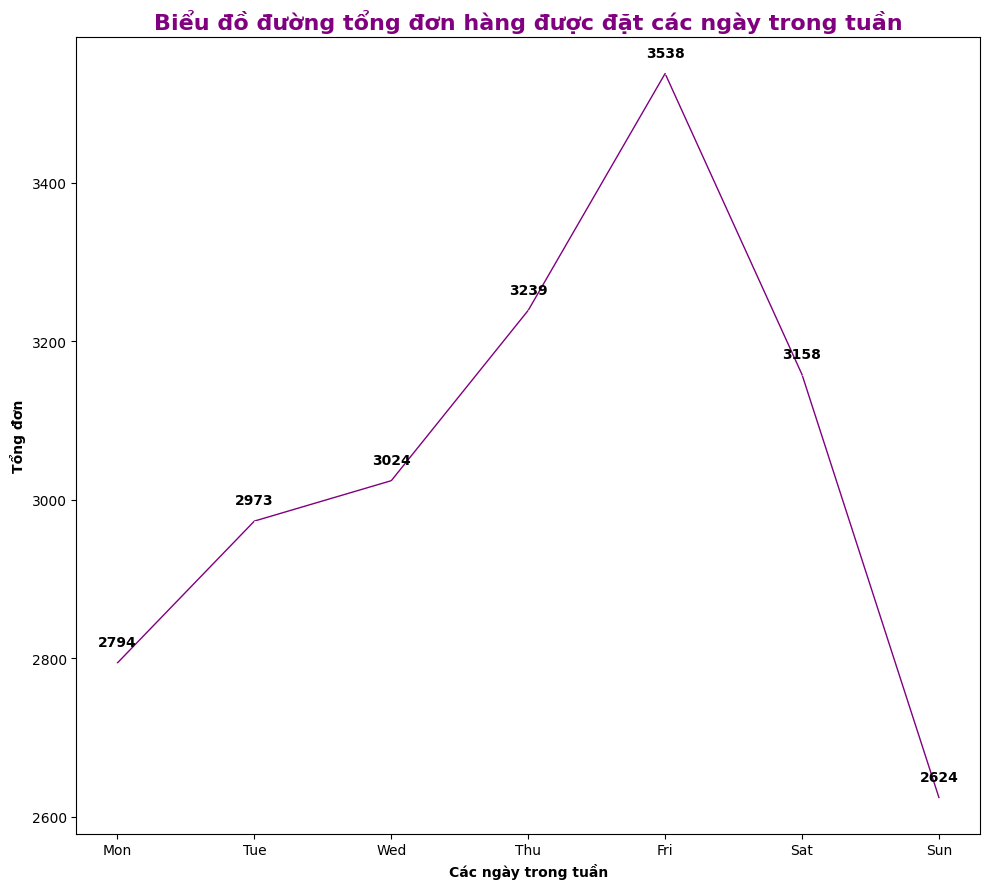

In [61]:
plt.figure(figsize=(10,9))
ax =sns.lineplot(x='DayWeek', y='order_id',data=df9, color='Purple', linewidth=1.0,marker=True)
for i, row in df9.iterrows():
    ax.annotate(f'{row['order_id']}',
                (row['DayWeek'],row['order_id']),
                textcoords='offset points',
                xytext=(0,12),ha='center',
                fontsize=10, fontweight='bold')
plt.title('Biểu đồ đường tổng đơn hàng được đặt các ngày trong tuần', fontweight='bold', fontsize=16, color='Purple')
plt.ylabel('Tổng đơn',fontweight='bold')
plt.xlabel('Các ngày trong tuần',fontweight='bold')
plt.tight_layout()


In [62]:
df10 = df.groupby('pizza_category')['order_id'].sum().reset_index()

In [63]:
df10

,pizza_category,order_id
0,Chicken,116070758
1,Classic,156514570
2,Supreme,126075892
3,Veggie,121644726


In [64]:
import plotly.express as px

In [68]:
plt.Figure(figsize=(10,9))
fig=px.funnel(df10, x='order_id',y='pizza_category',
          color='pizza_category',
          title='Biểu đồ tổng số lượng đơn hàng theo phân loại pizza',labels={'pizza_category':'Loại Pizza',"order_id":"Tổng đơn hàng"})
fig.show()